#  Hypertension Analysis - Feature Engineering

#### Objective

Use feature engineering to transform the relational TinyEHR tables into a patient-level dataset.

We will execute the following tasks:

- SQL extraction
- Patient demographics
- Target variable - hypertension
- Laboratory aggregation
- Blood pressure vitals aggregation
- Admissions aggregation
- Diagnoses aggregation
- Missing value assessment
- Correlation heatmap
- Feature distribution plot
- Exporting the final dataset

#### Import libraries

In [1]:
import sqlite3 as sql3
import pandas as pd
import os
import tinyehr
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

#### Connect to TinyEHR

In [2]:
tinyehr_db = r'C:\tinyehr\tinyehr_mimic_format.db'

if not os.path.exists(tinyehr_db):
    tinyehr.build_sqlite(format='tinyehr_mimic_format', output='tinyehr_db')

con = sql3.connect(tinyehr_db)

In [3]:
query = 'select name from sqlite_master where type="table" order by name'
tables = pd.read_sql(query, con)
tables

,name
0,admissions
1,caregiver
2,chartevents
3,d_hcpcs
4,d_icd_diagnoses
5,d_icd_procedures
6,d_items
7,d_labitems
8,date_offsets
9,datetimeevents


#### Extract Patients

In [4]:
query = 'select subject_id, gender, anchor_age from patients'
patients = pd.read_sql(query, con)
patients.head(3)

,subject_id,gender,anchor_age
0,10014729,F,21
1,10003400,F,72
2,10002428,F,80


Convert gender:

In [5]:
patients['gender'] = patients['gender'].map({'M': 1, 'F': 0})

Rename age:

In [6]:
patients.rename(columns={'anchor_age': 'age'}, inplace=True) 

In [7]:
patients.head(3)

,subject_id,gender,age
0,10014729,0,21
1,10003400,0,72
2,10002428,0,80


#### Create Target Variable

We only capture those primary/essential hypertension as our target:

In [8]:
query = 'select * from d_icd_diagnoses where long_title like "%essential%hypertension"'
dic = pd.read_sql(query, con)
dic

,icd_code,icd_version,long_title
0,401.0,9,Malignant essential hypertension
1,401.9,9,Unspecified essential hypertension
2,401.1,9,Benign essential hypertension
3,I10,10,Essential (primary) hypertension


In [9]:
query = 'select distinct subject_id, 1 as hypertension from diagnoses_icd where icd_code like "401%" or icd_code like "I10%"'
hypertension = pd.read_sql(query, con)
hypertension.head(3)

,subject_id,hypertension
0,10018501,1
1,10001217,1
2,10023771,1


Find patients with hypertension:

In [10]:
patients = patients.merge(hypertension, on='subject_id', how='left')
patients['hypertension'] = patients['hypertension'].round().astype('Int64')
patients.head(3)

,subject_id,gender,age,hypertension
0,10014729,0,21,<NA>
1,10003400,0,72,1
2,10002428,0,80,1


Replace missing values to 0s:

In [11]:
patients['hypertension'] = patients['hypertension'].fillna(0)
patients.head(3)

,subject_id,gender,age,hypertension
0,10014729,0,21,0
1,10003400,0,72,1
2,10002428,0,80,1


In [12]:
patients['hypertension'].isnull().sum()

0

#### Laboratory Feature Engineering

Select glucose, sodium and creatinine, which may be highly connected to primary hypertension, for the lab features:

In [13]:
query = 'select * from d_labitems where itemid in (50931,50912,50983)'
lab_dic = pd.read_sql(query, con)
lab_dic.head(3)

,itemid,label,fluid,category
0,50983,Sodium,Blood,Chemistry
1,50931,Glucose,Blood,Chemistry
2,50912,Creatinine,Blood,Chemistry


In [14]:
query = 'select * from labevents'
lab_table = pd.read_sql(query, con)
lab_table.head(3)

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,172061,10014354,29600294.0,1808066,51277,,2016-08-16 00:00:00,2016-08-16 01:30:00,15.4,15.40,%,10.5,15.5,,ROUTINE,
1,172062,10014354,29600294.0,1808066,51279,,2016-08-16 00:00:00,2016-08-16 01:30:00,3.35,3.35,m/uL,4.6,6.1,abnormal,ROUTINE,
2,172068,10014354,29600294.0,1808066,52172,,2016-08-16 00:00:00,2016-08-16 01:30:00,49.7,49.70,fL,35.1,46.3,abnormal,ROUTINE,


Aggregate lab results, only include glucose (50931), sodium (50983) and creatinine (50912):

In [15]:
query = """
select subject_id,
    avg(case when itemid=50931 then valuenum end) glucose_mean,
    max(case when itemid=50931 then valuenum end) glucose_max,
    min(case when itemid=50931 then valuenum end) glucose_min,
    avg(case when itemid=50912 then valuenum end) creatinine_mean,
    avg(case when itemid=50983 then valuenum end) sodium_mean
from labevents 
GROUP BY subject_id
"""
labs = pd.read_sql(query, con)
labs.head(3)

,subject_id,glucose_mean,glucose_max,glucose_min,creatinine_mean,sodium_mean
0,10000032,106.176471,155.0,71.0,0.466667,128.700000
1,10001217,96.363636,113.0,86.0,0.491667,140.090909
2,10001725,126.285714,152.0,92.0,0.808000,139.280000


#### Blood Pressure Features

Get diastolic (220180) and systolic (220179) blood pressure info:

In [16]:
query = 'select * from d_items where itemid in (220179, 220180)'
bp_dic = pd.read_sql(query, con)
bp_dic.head(3)

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,220180,Non Invasive Blood Pressure diastolic,NBPd,chartevents,Routine Vital Signs,mmHg,Numeric,None,None
1,220179,Non Invasive Blood Pressure systolic,NBPs,chartevents,Routine Vital Signs,mmHg,Numeric,None,None


In [17]:
query = 'select * from chartevents where itemid in (220179, 220180)'
bp = pd.read_sql(query, con)
bp.head(3)

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
0,10005817,20626031,32604416,79166,2016-12-16 15:00:00,2016-12-16 15:16:00,220179,112,112.0,mmHg,0
1,10005817,20626031,32604416,79166,2016-12-16 15:00:00,2016-12-16 15:16:00,220180,41,41.0,mmHg,0
2,10005817,20626031,32604416,79166,2016-12-16 16:00:00,2016-12-16 16:14:00,220179,117,117.0,mmHg,0


Aggregate diastolic and systolic measurements for each patient:

In [18]:
query = """
select subject_id,
avg(case when itemid=220179 then valuenum end) systolic_mean, 
max(case when itemid=220179 then valuenum end) systolic_max, 
avg(case when itemid=220180 then valuenum end) diastolic_mean, 
max(case when itemid=220180 then valuenum end) diastolic_max
from chartevents
group by subject_id
"""
bp_vitals = pd.read_sql(query, con)
bp_vitals.head(3)

,subject_id,systolic_mean,systolic_max,diastolic_mean,diastolic_max
0,10000032,88.90000,95.0,54.1000,59.0
1,10001217,126.90000,167.0,77.7200,123.0
2,10001725,100.40625,119.0,61.1875,83.0


#### Admission Features

Count number of admissions, first admission year, latest admission year, average length of stay per patient:

In [19]:
query = 'select * from admissions'
admsn = pd.read_sql(query, con)
admsn.head(3)

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2014-02-24 14:38:00,2014-03-04 14:02:00,None,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2014-02-24 12:15:00,2014-02-24 17:07:00,0
1,10009628,25926192,2013-09-17 17:08:00,2013-09-25 13:20:00,None,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,None,None,0
2,10018081,23983182,2014-08-18 02:02:00,2014-08-23 19:35:00,None,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2014-08-17 16:24:00,2014-08-18 03:15:00,0


In [20]:
query = """
select subject_id, 
count(*) as num_admissions,
cast(min(strftime('%Y', admittime)) AS integer) AS first_admission_year,
cast(max(strftime('%Y', admittime)) AS integer) AS latest_admission_year,
avg((julianday(dischtime) - julianday(admittime))) AS avg_stay_days
from admissions 
group by subject_id
"""
admissions = pd.read_sql(query, con)
admissions.head(3)

,subject_id,num_admissions,first_admission_year,latest_admission_year,avg_stay_days
0,10000032,4,2016,2016,1.444444
1,10001217,2,2013,2013,6.354514
2,10001725,1,2011,2011,2.994444


#### Diagnosis Features

Count the number of diagnosis per patient:

In [21]:
query = 'select * from diagnoses_icd'
diag = pd.read_sql(query, con)
diag.head(3)

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10035185,22580999,3,413.9,9
1,10035185,22580999,10,V70.7,9
2,10035185,22580999,1,414.01,9


In [22]:
query = 'select subject_id, count(distinct icd_code) as num_diagnosis from diagnoses_icd group by subject_id'
diagnoses = pd.read_sql(query, con)
diagnoses.head(3)

,subject_id,num_diagnosis
0,10000032,21
1,10001217,12
2,10001725,18


#### Prescription Features

In [23]:
query = 'select * from prescriptions'
presp = pd.read_sql(query, con)
presp.head(3)

,subject_id,hadm_id,pharmacy_id,poe_id,poe_seq,order_provider_id,starttime,stoptime,drug_type,drug,...,gsn,ndc,prod_strength,form_rx,dose_val_rx,dose_unit_rx,form_val_disp,form_unit_disp,doses_per_24_hrs,route
0,10027602,28166872,27168639,,NaN,,2014-10-30 12:00:00,None,MAIN,Fentanyl Citrate,...,,,,,,,,,NaN,
1,10027602,28166872,40720238,,NaN,,2014-10-30 12:00:00,None,MAIN,Fentanyl Citrate,...,,,,,,,,,NaN,
2,10027602,28166872,62845687,,NaN,,2014-10-31 12:00:00,None,MAIN,Lorazepam,...,,,,,,,,,NaN,


Count drugs for each patient:

In [24]:
query = 'select subject_id, count(distinct drug) as num_medication from prescriptions group by subject_id'
prescriptions = pd.read_sql(query, con)
prescriptions.head(3)

,subject_id,num_medication
0,10000032,32
1,10001217,32
2,10001725,35


#### Merge Features
- patients
- labs
- blood pressure vitals
- admissions
- diagnoses
- prescriptions

In [25]:
model_df = (
    patients.merge(labs, on='subject_id', how='left')
            .merge(bp_vitals, on='subject_id', how='left')
            .merge(admissions, on='subject_id', how='left')
            .merge(diagnoses, on='subject_id', how='left')
            .merge(prescriptions, on='subject_id', how='left')
)

Move the target "hypertension" to the last column:

In [26]:
col_name = 'hypertension'
cols = [c for c in model_df.columns if c != col_name] + [col_name]
model_df = model_df[cols]

#### Insepct Merged Dataset

In [27]:
model_df.head(3)

,subject_id,gender,age,glucose_mean,glucose_max,glucose_min,creatinine_mean,sodium_mean,systolic_mean,systolic_max,diastolic_mean,diastolic_max,num_admissions,first_admission_year,latest_admission_year,avg_stay_days,num_diagnosis,num_medication,hypertension
0,10014729,0,21,95.315789,140.0,74.0,0.580000,138.000000,100.000000,122.0,45.500000,56.0,2,2013,2013,8.079514,18,75,0
1,10003400,0,72,113.030612,159.0,70.0,1.053333,137.925926,98.127968,142.0,59.662269,109.0,7,2011,2014,11.737004,113,123,1
2,10002428,0,80,108.400000,183.0,67.0,0.598529,135.527027,106.193103,163.0,57.958621,130.0,7,2011,2016,5.621230,84,97,1


In [28]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subject_id             100 non-null    int64  
 1   gender                 100 non-null    int64  
 2   age                    100 non-null    int64  
 3   glucose_mean           100 non-null    float64
 4   glucose_max            100 non-null    float64
 5   glucose_min            100 non-null    float64
 6   creatinine_mean        100 non-null    float64
 7   sodium_mean            100 non-null    float64
 8   systolic_mean          100 non-null    float64
 9   systolic_max           100 non-null    float64
 10  diastolic_mean         100 non-null    float64
 11  diastolic_max          100 non-null    float64
 12  num_admissions         100 non-null    int64  
 13  first_admission_year   100 non-null    int64  
 14  latest_admission_year  100 non-null    int64  
 15  avg_sta

No missing values for all features and target variable.

In [29]:
model_df.describe()

,subject_id,gender,age,glucose_mean,glucose_max,glucose_min,creatinine_mean,sodium_mean,systolic_mean,systolic_max,diastolic_mean,diastolic_max,num_admissions,first_admission_year,latest_admission_year,avg_stay_days,num_diagnosis,num_medication,hypertension
count,1.000000e+02,100.00000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.0000,100.000000,100.000000,100.000000,100.00000,100.000000,100.0
mean,1.001878e+07,0.57000,61.75000,135.396895,246.390000,83.760000,1.300715,138.061858,118.481079,151.66000,64.147572,95.800000,2.7500,2013.750000,2014.890000,7.221432,32.23000,55.710000,0.53
std,1.115115e+04,0.49757,16.16979,39.059294,173.843242,24.339816,1.300913,3.571682,14.535183,21.76097,9.226065,21.759011,3.1794,1.777383,2.373656,4.733735,31.40059,30.368543,0.501614
min,1.000003e+07,0.00000,21.00000,89.954545,110.000000,29.000000,0.305556,126.347826,88.900000,95.00000,35.405660,56.000000,1.0000,2011.000000,2011.000000,1.444444,3.00000,12.000000,0.0
25%,1.000889e+07,0.00000,51.75000,106.132353,140.000000,70.750000,0.632143,135.968391,108.284638,139.00000,59.319751,80.750000,1.0000,2012.000000,2013.000000,4.253950,11.00000,34.250000,0.0
50%,1.001909e+07,1.00000,63.00000,120.933333,186.000000,83.000000,0.907143,138.027778,116.491667,153.50000,63.554348,92.500000,1.0000,2014.000000,2015.000000,5.847569,21.00000,49.000000,1.0
75%,1.002550e+07,1.00000,72.00000,151.117647,297.000000,92.250000,1.290625,140.000000,128.089286,164.00000,68.727273,110.750000,3.0000,2015.000000,2016.000000,9.031337,41.00000,68.750000,1.0
max,1.004002e+07,1.00000,91.00000,256.142857,996.000000,165.000000,9.811111,148.117647,158.000000,215.00000,88.691450,162.000000,20.0000,2017.000000,2022.000000,31.307639,160.00000,178.000000,1.0


In [30]:
model_df.shape

(100, 19)

#### Missing Values

As we mentioned above, there are no missing values for each feature at this step. But We can reassure it.

In [31]:
missing = model_df.isna().sum().sort_values(ascending=False)
missing

subject_id               0
diastolic_mean           0
num_medication           0
num_diagnosis            0
avg_stay_days            0
latest_admission_year    0
first_admission_year     0
num_admissions           0
diastolic_max            0
systolic_max             0
gender                   0
systolic_mean            0
sodium_mean              0
creatinine_mean          0
glucose_min              0
glucose_max              0
glucose_mean             0
age                      0
hypertension             0
dtype: int64

#### Feature Correlation

Get the correlation matrix of all features:

In [32]:
corr = model_df.corr(numeric_only=True)
corr

,subject_id,gender,age,glucose_mean,glucose_max,glucose_min,creatinine_mean,sodium_mean,systolic_mean,systolic_max,diastolic_mean,diastolic_max,num_admissions,first_admission_year,latest_admission_year,avg_stay_days,num_diagnosis,num_medication,hypertension
subject_id,1.000000,-0.028387,0.071547,0.175812,0.119845,-0.113426,0.100314,0.119743,0.151622,0.152905,0.113802,0.042923,0.009769,0.037091,0.104055,0.061235,0.111839,0.109244,0.031973
gender,-0.028387,1.000000,0.050533,-0.047935,-0.045803,0.121505,0.187572,0.056574,0.038737,0.012482,0.114131,-0.119981,-0.094180,0.037120,-0.074663,0.121484,-0.091229,0.051159,-0.170382
age,0.071547,0.050533,1.000000,0.059437,0.072632,0.025562,0.154053,0.120333,0.079699,0.185918,-0.194614,0.114291,-0.038166,-0.104121,-0.068096,-0.066575,0.092582,-0.040240,0.317875
glucose_mean,0.175812,-0.047935,0.059437,1.000000,0.672967,0.126720,0.041032,-0.209263,0.085500,0.186347,-0.134680,0.065614,0.104830,0.063194,0.132169,0.155768,0.204063,0.199778,0.068451
glucose_max,0.119845,-0.045803,0.072632,0.672967,1.000000,-0.292093,0.130482,-0.123922,-0.077962,0.128016,-0.158239,0.198823,0.346365,-0.082324,0.217501,0.145264,0.415239,0.381717,0.061083
glucose_min,-0.113426,0.121505,0.025562,0.126720,-0.292093,1.000000,-0.111297,-0.001305,0.282374,-0.021934,0.071682,-0.213075,-0.500834,0.105537,-0.356252,-0.158234,-0.549778,-0.453979,0.080019
creatinine_mean,0.100314,0.187572,0.154053,0.041032,0.130482,-0.111297,1.000000,0.068530,0.091808,0.283003,0.011787,0.080609,0.099120,0.004308,0.066864,0.076480,0.203649,0.128959,-0.222867
sodium_mean,0.119743,0.056574,0.120333,-0.209263,-0.123922,-0.001305,0.068530,1.000000,0.188697,0.143197,0.154881,0.167345,-0.131938,-0.063421,-0.012591,-0.000273,-0.094141,-0.111406,0.000025
systolic_mean,0.151622,0.038737,0.079699,0.085500,-0.077962,0.282374,0.091808,0.188697,1.000000,0.642396,0.492624,0.229320,-0.109919,0.006053,-0.163122,0.030080,-0.194448,-0.254333,0.190590
systolic_max,0.152905,0.012482,0.185918,0.186347,0.128016,-0.021934,0.283003,0.143197,0.642396,1.000000,0.290539,0.616799,0.117162,0.010055,-0.004251,0.308625,0.195186,0.148082,0.192496


Display the heatmap of the correlation matrix:

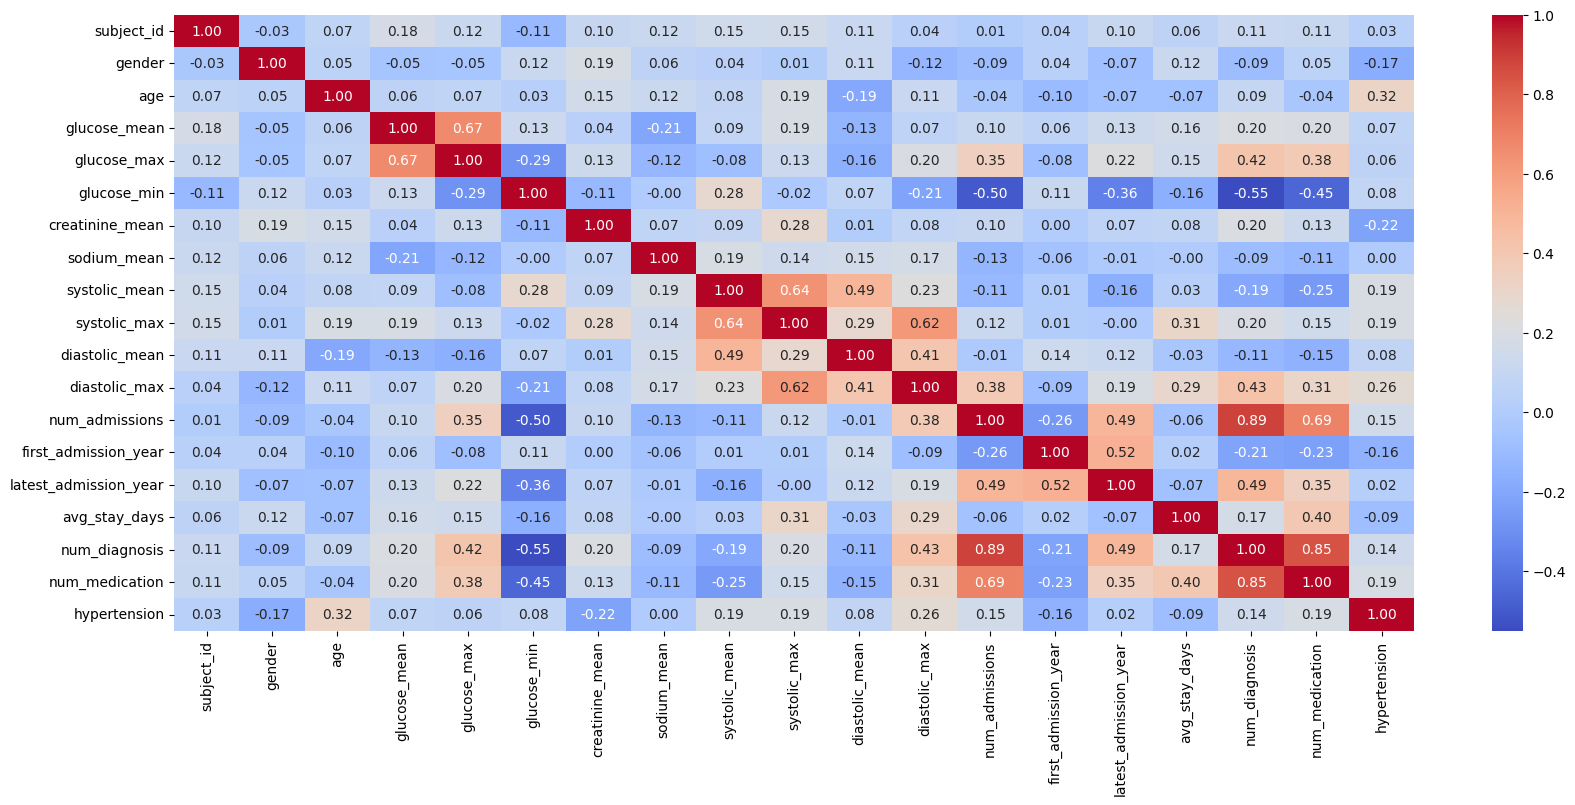

In [33]:
plt.figure(figsize=(20,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

The correlation matrix only between the target variable and all other features:

In [34]:
corr_target = corr[['hypertension']].iloc[:-1]
corr_target

,hypertension
subject_id,0.031973
gender,-0.170382
age,0.317875
glucose_mean,0.068451
glucose_max,0.061083
glucose_min,0.080019
creatinine_mean,-0.222867
sodium_mean,0.000025
systolic_mean,0.190590
systolic_max,0.192496


Correlation only measures linear relationships. Each feature may contributes a little. But the combination of them can provide more predictive information.

#### Plot Distribution

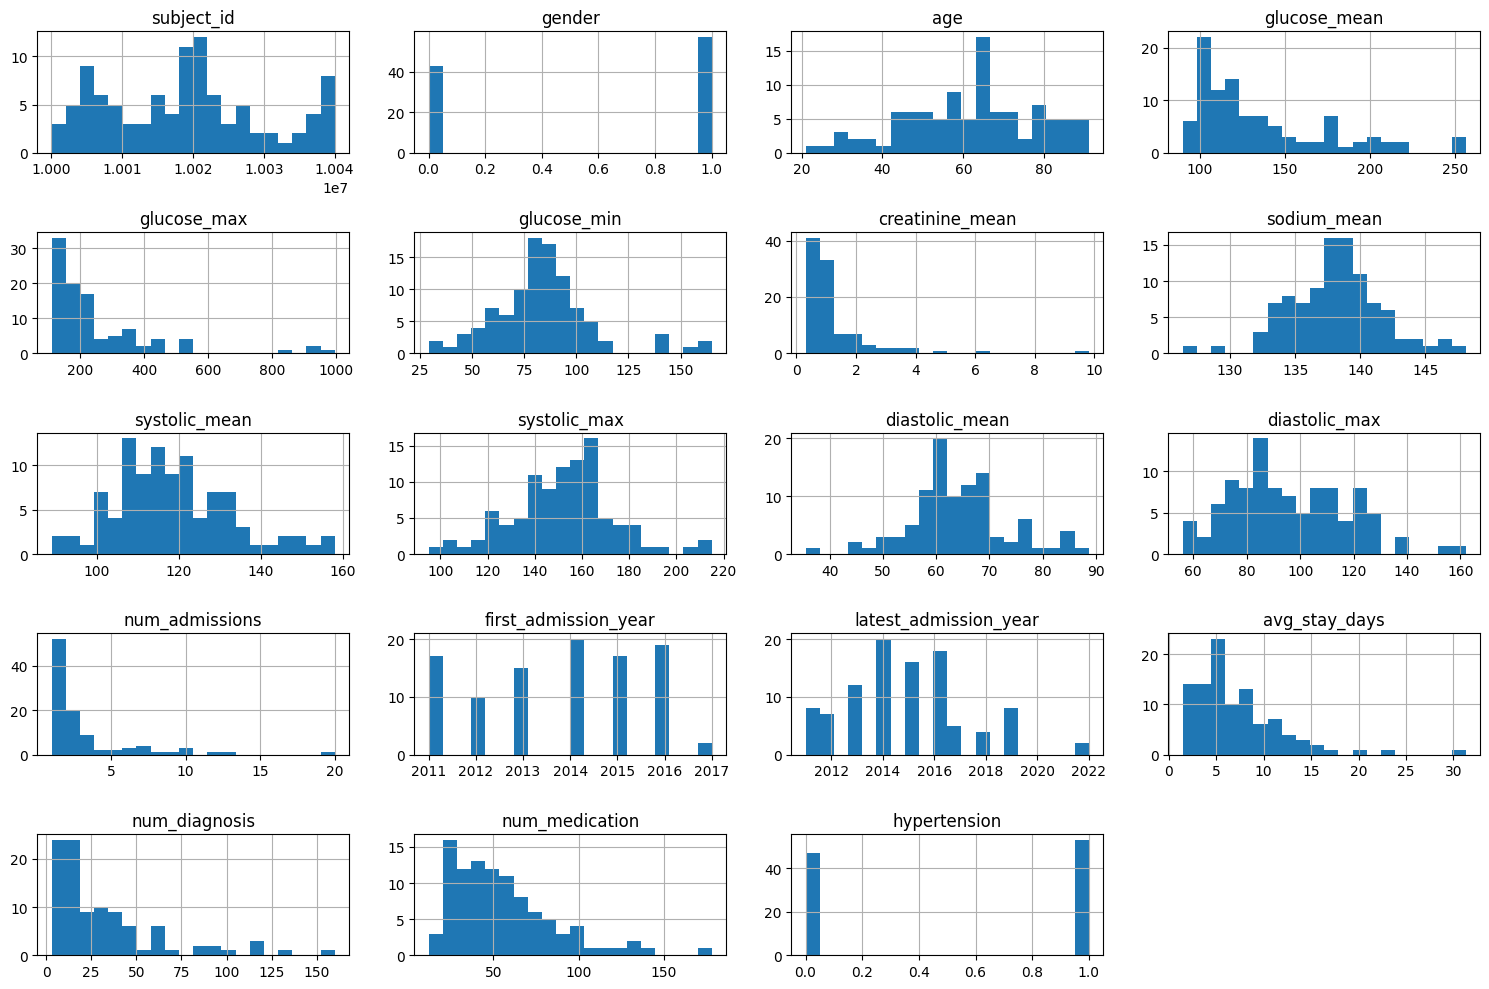

In [35]:
numeric = model_df.select_dtypes(include='number')
numeric.hist(figsize=(15,10), bins=20)
plt.tight_layout()

#### Export Dataset

In [36]:
outpath = Path('./data/hypertension_features.csv')
outdir = outpath.parent

if not outdir.exists():
    outdir.mkdir(parents=True, exist_ok=True)

model_df.to_csv(outpath, index=False)

#### Summary

In this notebook we extracte related data from multiple tables into a single patient-level dataset.

Key steps included:

- Extracting demographic information
- Creating a hypertension target variable
- Engineering laboratory, blood pressure measurements, admission and diagnosis features
- Assessing missing values
- Plotting feature correlation heatmap and distribution
- Exporting the final dataset

The resulting dataset will be used in the next notebook to train and evaluate models for hypertension prediction.